# Transformed Variables Model

**Workflow: Linear Regression with Transformed Variables**

This section explores how mathematical transformations impact the performance of Linear Regression. By addressing data skewness, scale disparities, and outliers, we aim to satisfy OLS assumptions and improve predictive accuracy.

* **Step 1: EDA & Preprocessing:** Analyze distributions to handle missing data by applying transformations to correct right-skewed data and standardizing feature scales, and encoding categorical features (Ordinal Mapping & N-1 One-Hot Encoding).
* **Step 2: Model Construction:** Build and compare four regression variants:
    * *Baseline Model:* Raw Features + Original Target
    * *Standard-BoxCox Model:* StandardScaler + Box-Cox Target
    * *Robust-BoxCox Model:* RobustScaler + Box-Cox Target
    * *Power-BoxCox Model:* PowerTransformer (Yeo-Johnson) + Box-Cox Target
* **Step 3: Evaluation:** Compare RMSE, MAE, and R-squared across models.
* **Step 4: Diagnostics & Insights:** Validate the best model using residual plots (checking for homoscedasticity) and interpret key coefficients.

## 1. Exploratory Data Analysis (EDA) and Preprocessing

Before applying any mathematical transformations, we must identify the structural issues within our dataset:
1. **Target Skewness:** Is the target variable (`Item_Outlet_Sales`) normally distributed or heavily skewed?
2. **Feature Scales & Outliers:** Do the numerical predictors have vastly different ranges or extreme outliers?
3. **Categorical Encoding:** Converting text data into machine-readable formats while preserving ordinal hierarchy and avoiding the Dummy Variable Trap.

**Load Data**

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from scipy.special import inv_boxcox
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

In [ ]:
# Load Train Set
X_train = pd.read_csv('../data/train_data/X_train.csv')
y_train = pd.read_csv('../data/train_data/y_train.csv')

# Load Test Set
X_test = pd.read_csv('../data/test_data/X_test.csv')
y_test = pd.read_csv('../data/test_data/y_test.csv')

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}   | y_test shape: {y_test.shape}")

X_train shape: (6818, 9) | y_train shape: (6818, 1)
X_test shape: (1705, 9)   | y_test shape: (1705, 1)


### 1.1 Target Variable Analysis (`Item_Outlet_Sales`)

**Objective:** Linear Regression assumes that the residuals are normally distributed, which is heavily influenced by the distribution of the target variable. Before modeling, we must check if `Item_Outlet_Sales` violates this assumption.

Skewness of Item_Outlet_Sales (Training Data): 1.178


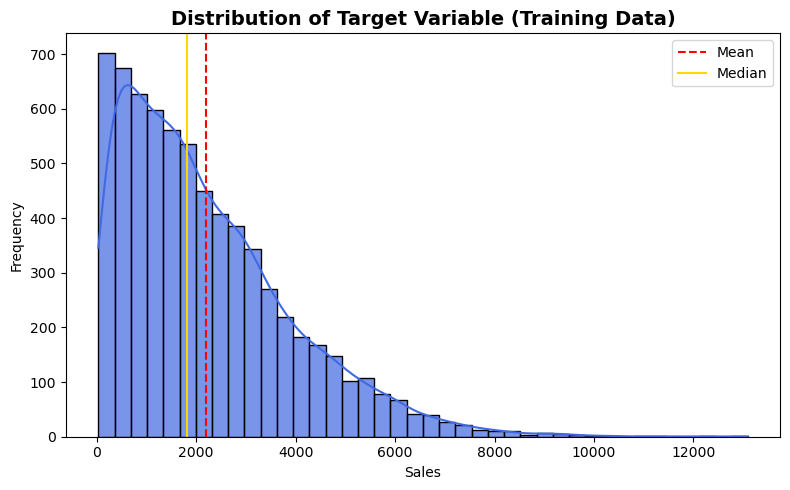

In [58]:
target_col = 'Item_Outlet_Sales' 

sales_skew = y_train[target_col].skew()
print(f"Skewness of {target_col} (Training Data): {sales_skew:.3f}")

plt.figure(figsize=(8, 5))
sns.histplot(y_train[target_col], kde=True, color='royalblue', bins=40, edgecolor='black', alpha=0.7)

# Mean and Median
plt.axvline(y_train[target_col].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(y_train[target_col].median(), color='gold', linestyle='-', label='Median')

plt.title('Distribution of Target Variable (Training Data)', fontweight='bold', fontsize=14)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**
* The target variable `Item_Outlet_Sales` is **highly right-skewed** (Skewness = **1.178**). 

**Transformation Strategy:**
* **Action:** We apply the **Box-Cox Transformation** to mathematically optimize the distribution.
* **Purpose:** Instead of guessing, Box-Cox automatically calculates the optimal lambda ($\lambda$) parameter to reshape the data into a symmetric, normal distribution without over-correcting. This effectively stabilizes error variance and strictly satisfies OLS Linear Regression assumptions.

--- Skewness Comparison ---
Original Skewness:      1.178
Box-Cox Skewness:       -0.074
Optimal Lambda:         0.3461
---------------------------


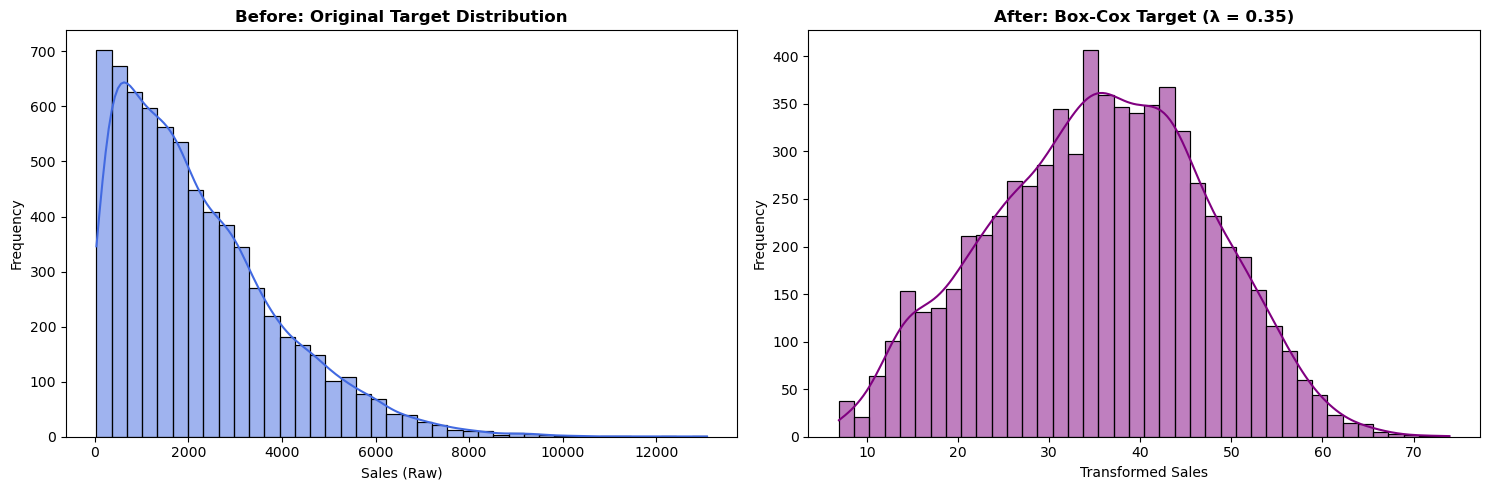

In [59]:
# 1. Apply Box-Cox Transformation
y_train_boxcox, fitted_lambda = stats.boxcox(y_train[target_col] + 1)

y_test_boxcox = stats.boxcox(y_test[target_col] + 1, lmbda=fitted_lambda)

y_train_boxcox_series = pd.Series(y_train_boxcox)

# 2. Skewness Comparison
print(f"--- Skewness Comparison ---")
print(f"Original Skewness:      {y_train[target_col].skew():.3f}")
print(f"Box-Cox Skewness:       {y_train_boxcox_series.skew():.3f}")
print(f"Optimal Lambda:         {fitted_lambda:.4f}")
print("-" * 27)

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw
sns.histplot(y_train[target_col], kde=True, color='royalblue', bins=40, ax=axes[0])
axes[0].set_title('Before: Original Target Distribution', fontweight='bold')
axes[0].set_xlabel('Sales (Raw)')
axes[0].set_ylabel('Frequency')

# After Box-Cox Transformed
sns.histplot(y_train_boxcox, kde=True, color='purple', bins=40, ax=axes[1])
axes[1].set_title(f'After: Box-Cox Target (\u03bb = {fitted_lambda:.2f})', fontweight='bold')
axes[1].set_xlabel('Transformed Sales')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1.2 Feature Variance & Outliers Analysis

**Objective:**
Linear Regression models are sensitive to the magnitude of input features and the presence of extreme outliers. We need to examine our numerical predictors (`Item_Weight`, `Item_Visibility`, `Item_MRP`) to determine if they require scaling or robust transformation prior to model training.

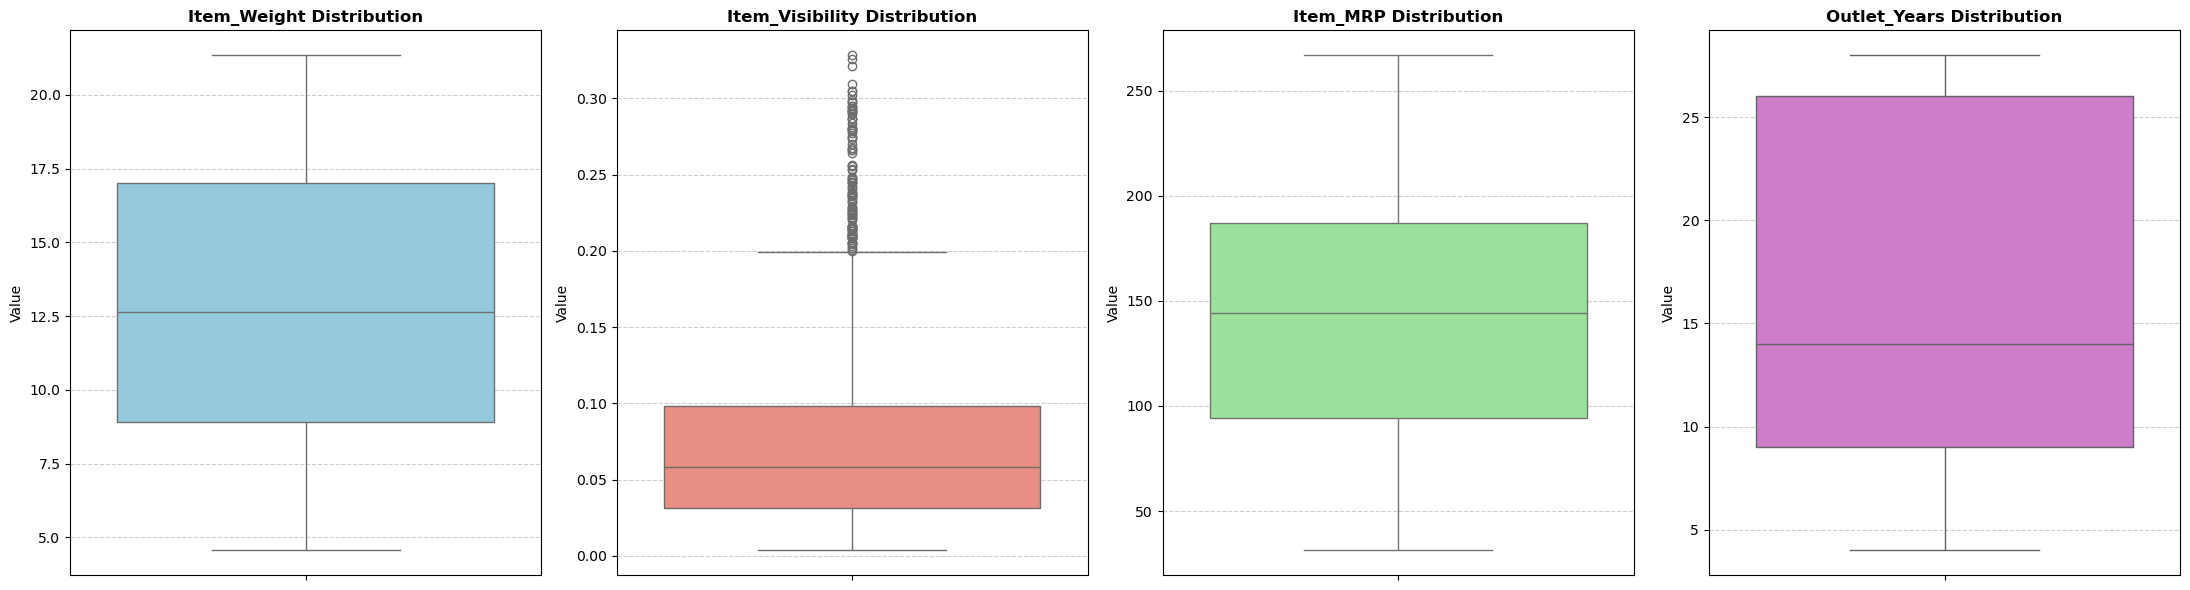

In [60]:
numeric_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']

num_features = [col for col in numeric_cols if col in X_train.columns]

# Create a figure with 4 subplots in a single row
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

# List of colors for variety
colors = ['skyblue', 'salmon', 'lightgreen', 'orchid']

# Loop through each feature to create a separate boxplot
for i, col in enumerate(num_features):
    sns.boxplot(y=X_train[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f'{col} Distribution', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Observation:**
* The summary statistics reveal a drastic disparity in the magnitude of the numerical features.
* `Item_MRP` dominates the numerical space with values ranging up to **266.88**, while `Item_Visibility` operates on a micro-scale, maxing out at only **0.328**. 

**Implication for Modeling:**
* OLS Linear Regression relies on minimizing the sum of squared residuals. If we feed this raw data into the model, the algorithm will naturally be biased towards `Item_MRP` simply because its numbers are larger, while virtually ignoring the impact of `Item_Visibility`. Furthermore, the coefficients ($\beta$) will be on entirely different scales, making them impossible to compare directly.

**Transformation Strategy:**
* **Action:** To ensure all features contribute fairly to the model's cost function, we must apply **Feature Scaling**. 
* In the next step, we will transform these variables using three different techniques (`StandardScaler`, `RobustScaler`, and `PowerTransformer`) and visualize how each method resolves this scale disparity and handles the underlying outliers.

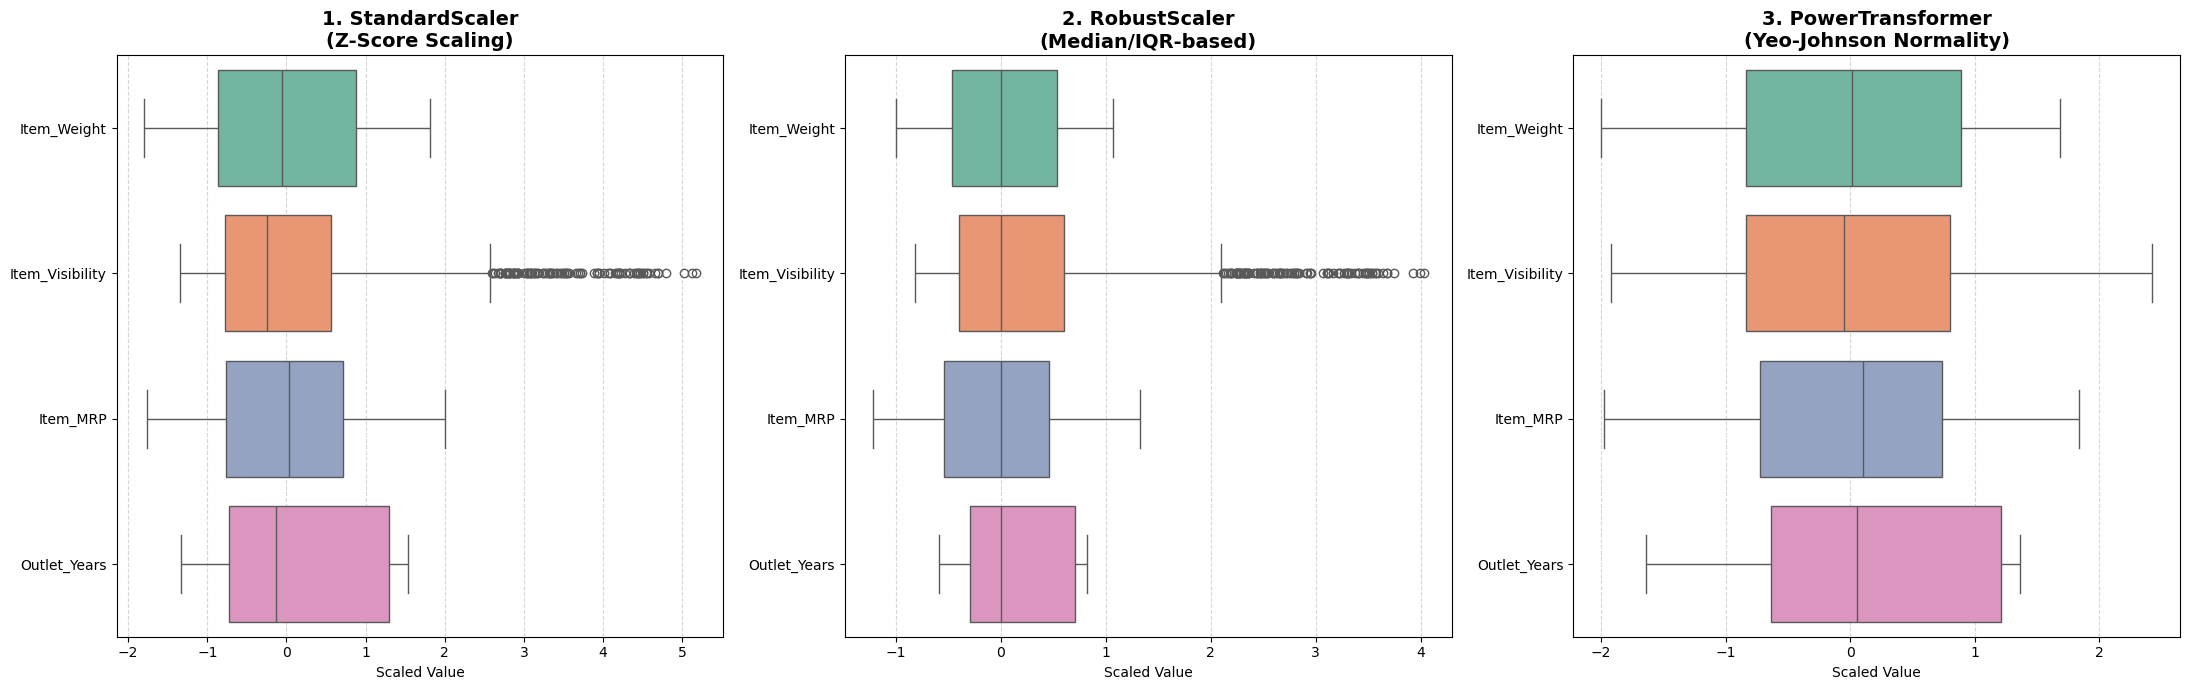

In [61]:
# 1. Create copies of X_train and X_test for model variants
X_train_std = X_train.copy()
X_test_std  = X_test.copy()

X_train_rob = X_train.copy()
X_test_rob  = X_test.copy()

X_train_pwr = X_train.copy()
X_test_pwr  = X_test.copy()

# 1. numerical features
num_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']
num_features = [col for col in num_features if col in X_train.columns]

# 2. Scalers
scaler_std = StandardScaler()
scaler_rob = RobustScaler()
scaler_pwr = PowerTransformer(method='yeo-johnson')

# 3. Fit & Transform
# StandardScaler
X_train_std[num_features] = scaler_std.fit_transform(X_train[num_features])
X_test_std[num_features]  = scaler_std.transform(X_test[num_features])

# RobustScaler
X_train_rob[num_features] = scaler_rob.fit_transform(X_train[num_features])
X_test_rob[num_features]  = scaler_rob.transform(X_test[num_features])

# PowerTransformer
X_train_pwr[num_features] = scaler_pwr.fit_transform(X_train[num_features])
X_test_pwr[num_features]  = scaler_pwr.transform(X_test[num_features])

# ==================================================
# FINAL SCALING COMPARISON
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: StandardScaler
sns.boxplot(data=X_train_std[num_features], ax=axes[0], palette='Set2', orient='h')
axes[0].set_title('1. StandardScaler\n(Z-Score Scaling)', fontweight='bold', fontsize=14)

# Plot 2: RobustScaler
sns.boxplot(data=X_train_rob[num_features], ax=axes[1], palette='Set2', orient='h')
axes[1].set_title('2. RobustScaler\n(Median/IQR-based)', fontweight='bold', fontsize=14)

# Plot 3: PowerTransformer
sns.boxplot(data=X_train_pwr[num_features], ax=axes[2], palette='Set2', orient='h')
axes[2].set_title('3. PowerTransformer\n(Yeo-Johnson Normality)', fontweight='bold', fontsize=14)

# Formatting
for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.set_xlabel('Scaled Value')

plt.tight_layout()
plt.show()

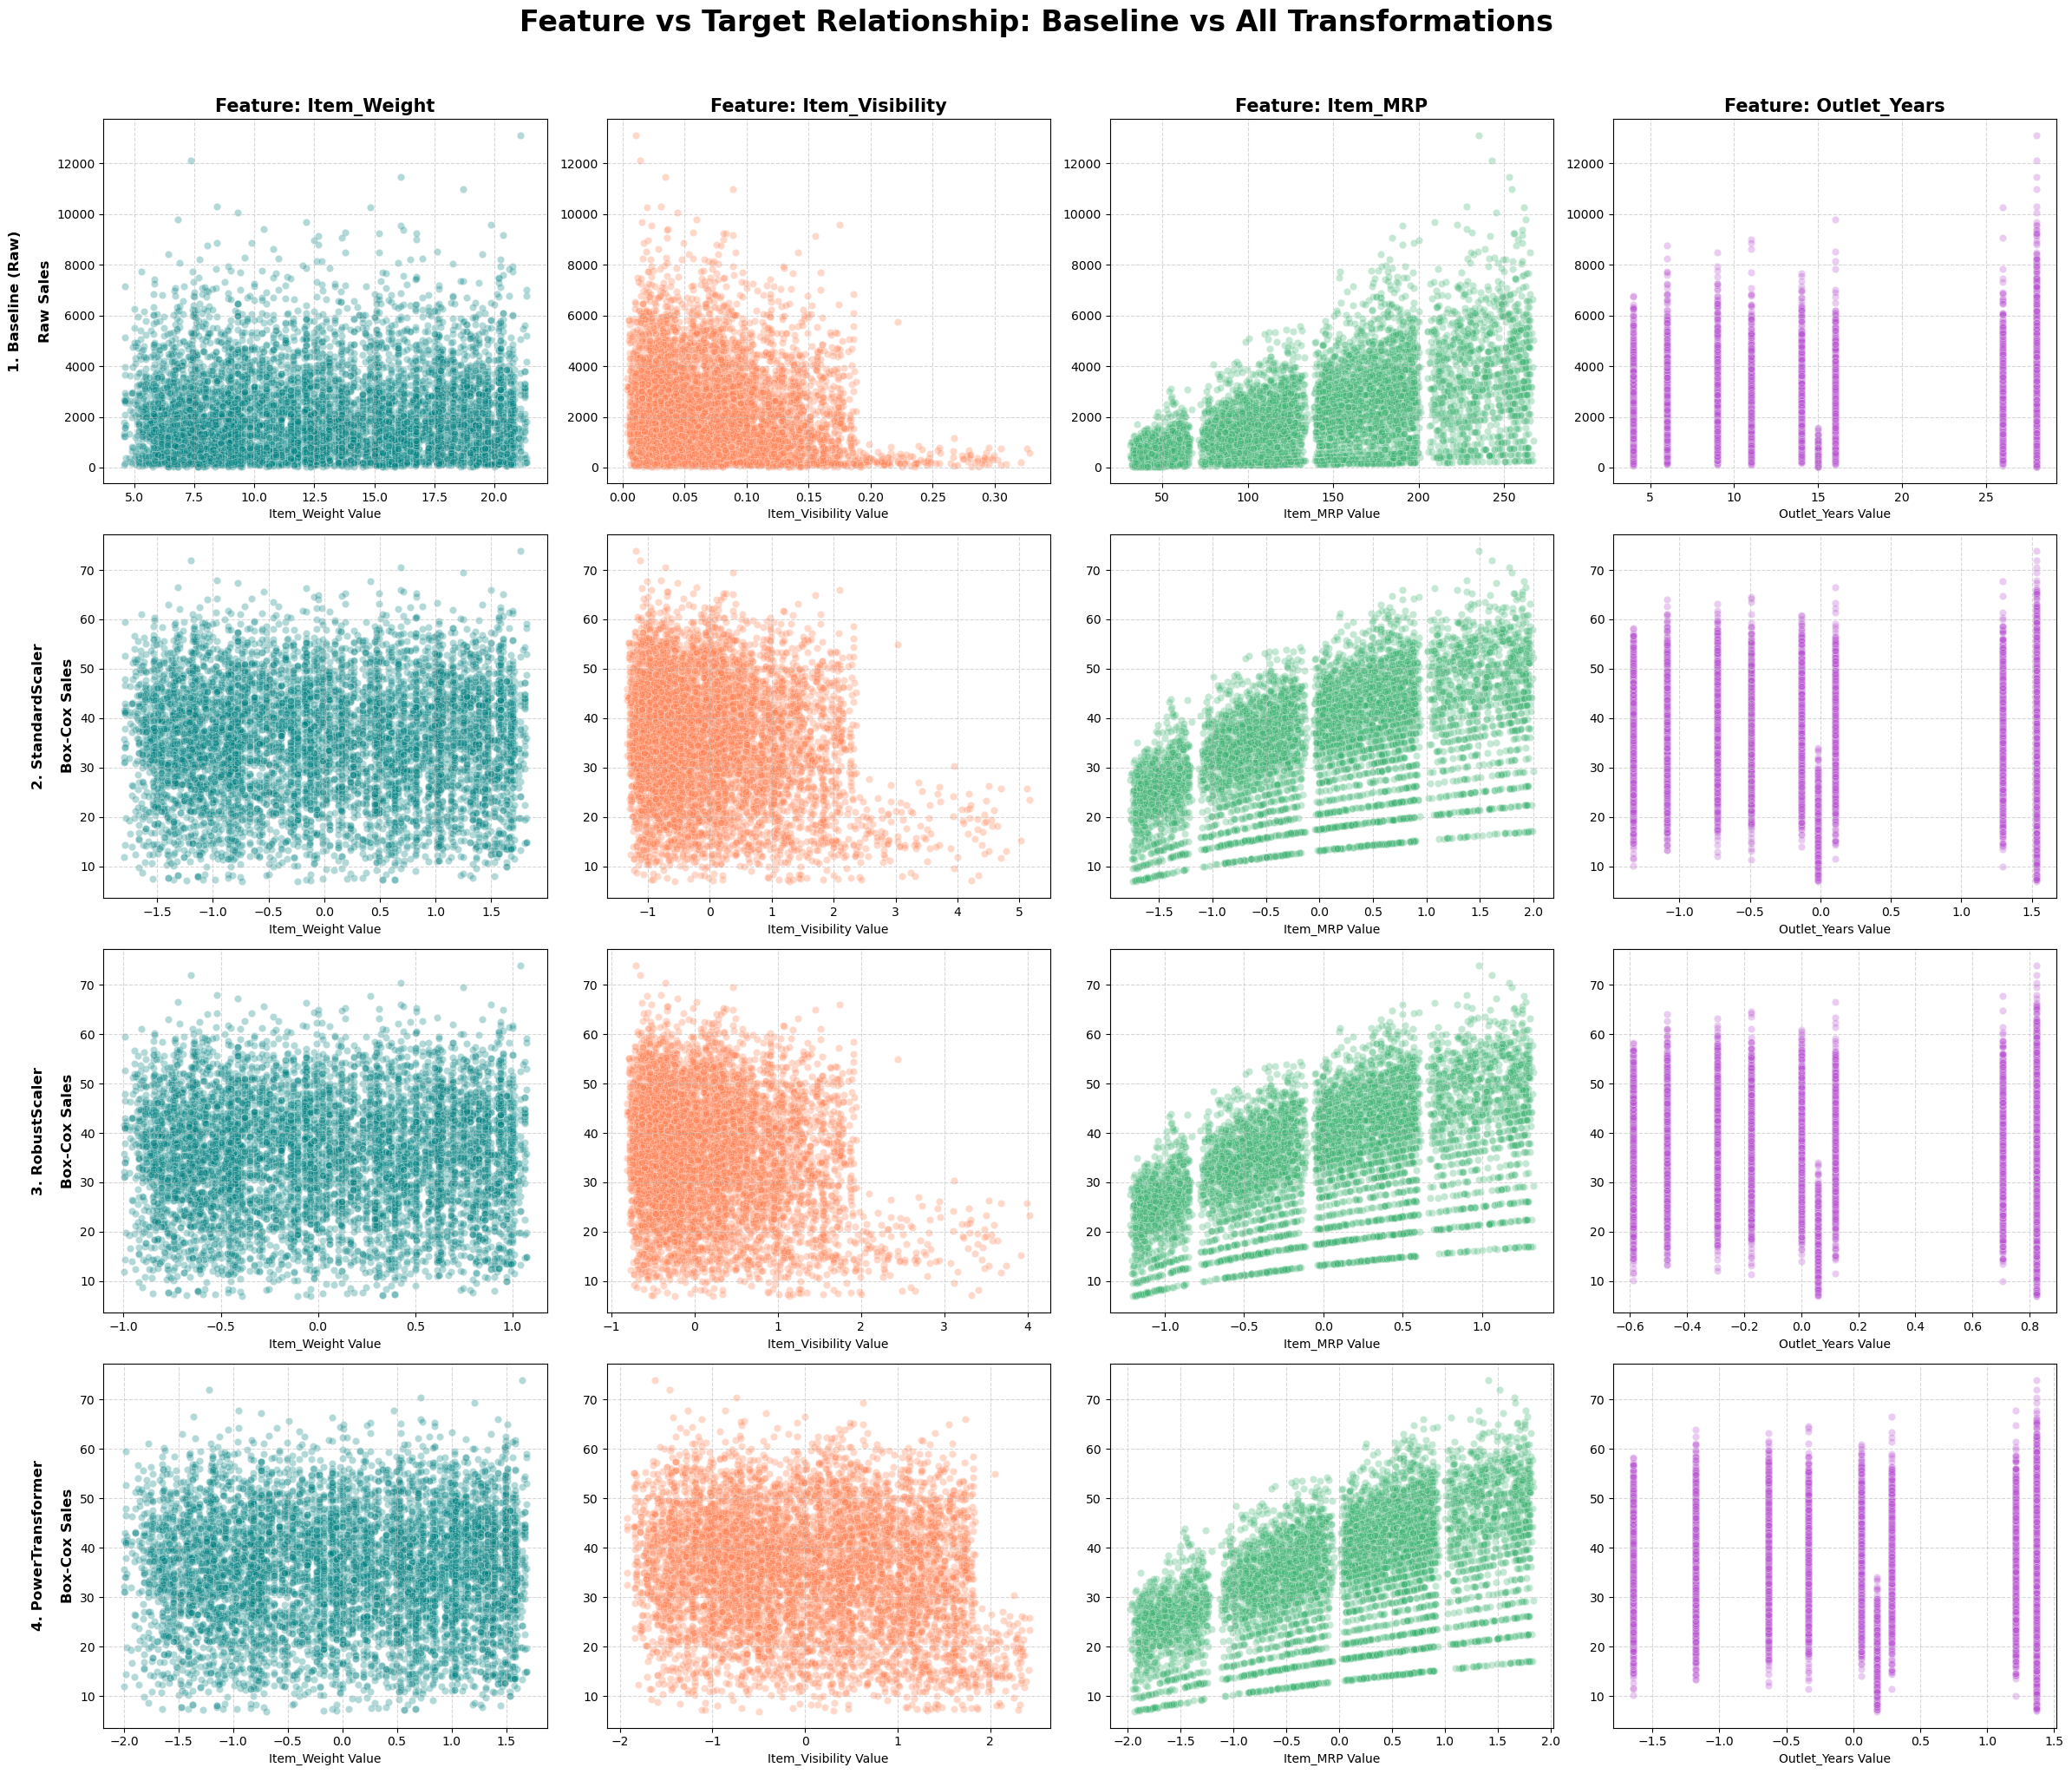

In [ ]:
# COMPREHENSIVE SCATTER PLOT MATRIX: BASELINE VS TRANSFORMATIONS

transformations = [
    ('1. Baseline (Raw)', X_train, y_train[target_col]),
    ('2. StandardScaler', X_train_std, y_train_boxcox),
    ('3. RobustScaler', X_train_rob, y_train_boxcox),
    ('4. PowerTransformer', X_train_pwr, y_train_boxcox)
]

# Create a 4x4 subplot grid
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
colors = ['teal', 'coral', 'mediumseagreen', 'mediumorchid']

# Loop through to plot all 16 scatter plots
for row_idx, (trans_name, X_data, y_data) in enumerate(transformations):
    for col_idx, col_name in enumerate(num_features):
        ax = axes[row_idx, col_idx]
        
        # Plot Scatter Plot
        sns.scatterplot(
            x=X_data[col_name], 
            y=y_data, 
            ax=ax, 
            color=colors[col_idx], 
            alpha=0.3
        )
        
        # Set column titles on the top row
        if row_idx == 0:
            ax.set_title(f"Feature: {col_name}", fontweight='bold', fontsize=15)
            
        # Set X-axis label
        ax.set_xlabel(f"{col_name} Value")
        
        # Set Y-axis label and Row name on the leftmost column
        if col_idx == 0:
            target_label = 'Raw Sales' if row_idx == 0 else 'Box-Cox Sales'
            ax.set_ylabel(f"{trans_name}\n\n{target_label}", fontweight='bold', fontsize=12)
        else:
            ax.set_ylabel('')
            
        ax.grid(True, linestyle='--', alpha=0.5)

# Adjust layout and display the plot
plt.suptitle("Feature vs Target Relationship: Baseline vs All Transformations", fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation**
- **StandardScaler**: Preserves the exact original distribution. Consequently, the extreme right-tail outliers in `Item_Visibility` still stretch as far as 5 standard deviations from the mean.

- **RobustScaler**: Uses the median and IQR, resulting in more consistent "boxes" across all features. However, it still leaves the `Item_Visibility` outliers prominent, reaching up to 4 units.

- **PowerTransformer (Yeo-Johnson)**: This is the most effective transformation for this dataset. It significantly compresses the outliers of Item_Visibility, pulling them closer to the central distribution and creating a much more symmetric.

**Numerical Features Scaling Justification**

- **StandardScaler**  
  Rescales features to mean = 0 and std = 1 → suitable for near-normal data and makes coefficients comparable. Sensitive to outliers.
- **RobustScaler**  
  Uses median and IQR → robust to outliers, suitable for skewed data. Does not normalize the distribution.
- **PowerTransformer**  
  Transforms data toward normality → reduces skewness and stabilizes variance, improving linear model assumptions. Less interpretable.

### 1.3 Categorical Feature Engineering & Validation
To transform categorical variables into a numerical format that machine learning algorithms can process effectively, ensuring that the mathematical relationships between categories are preserved.

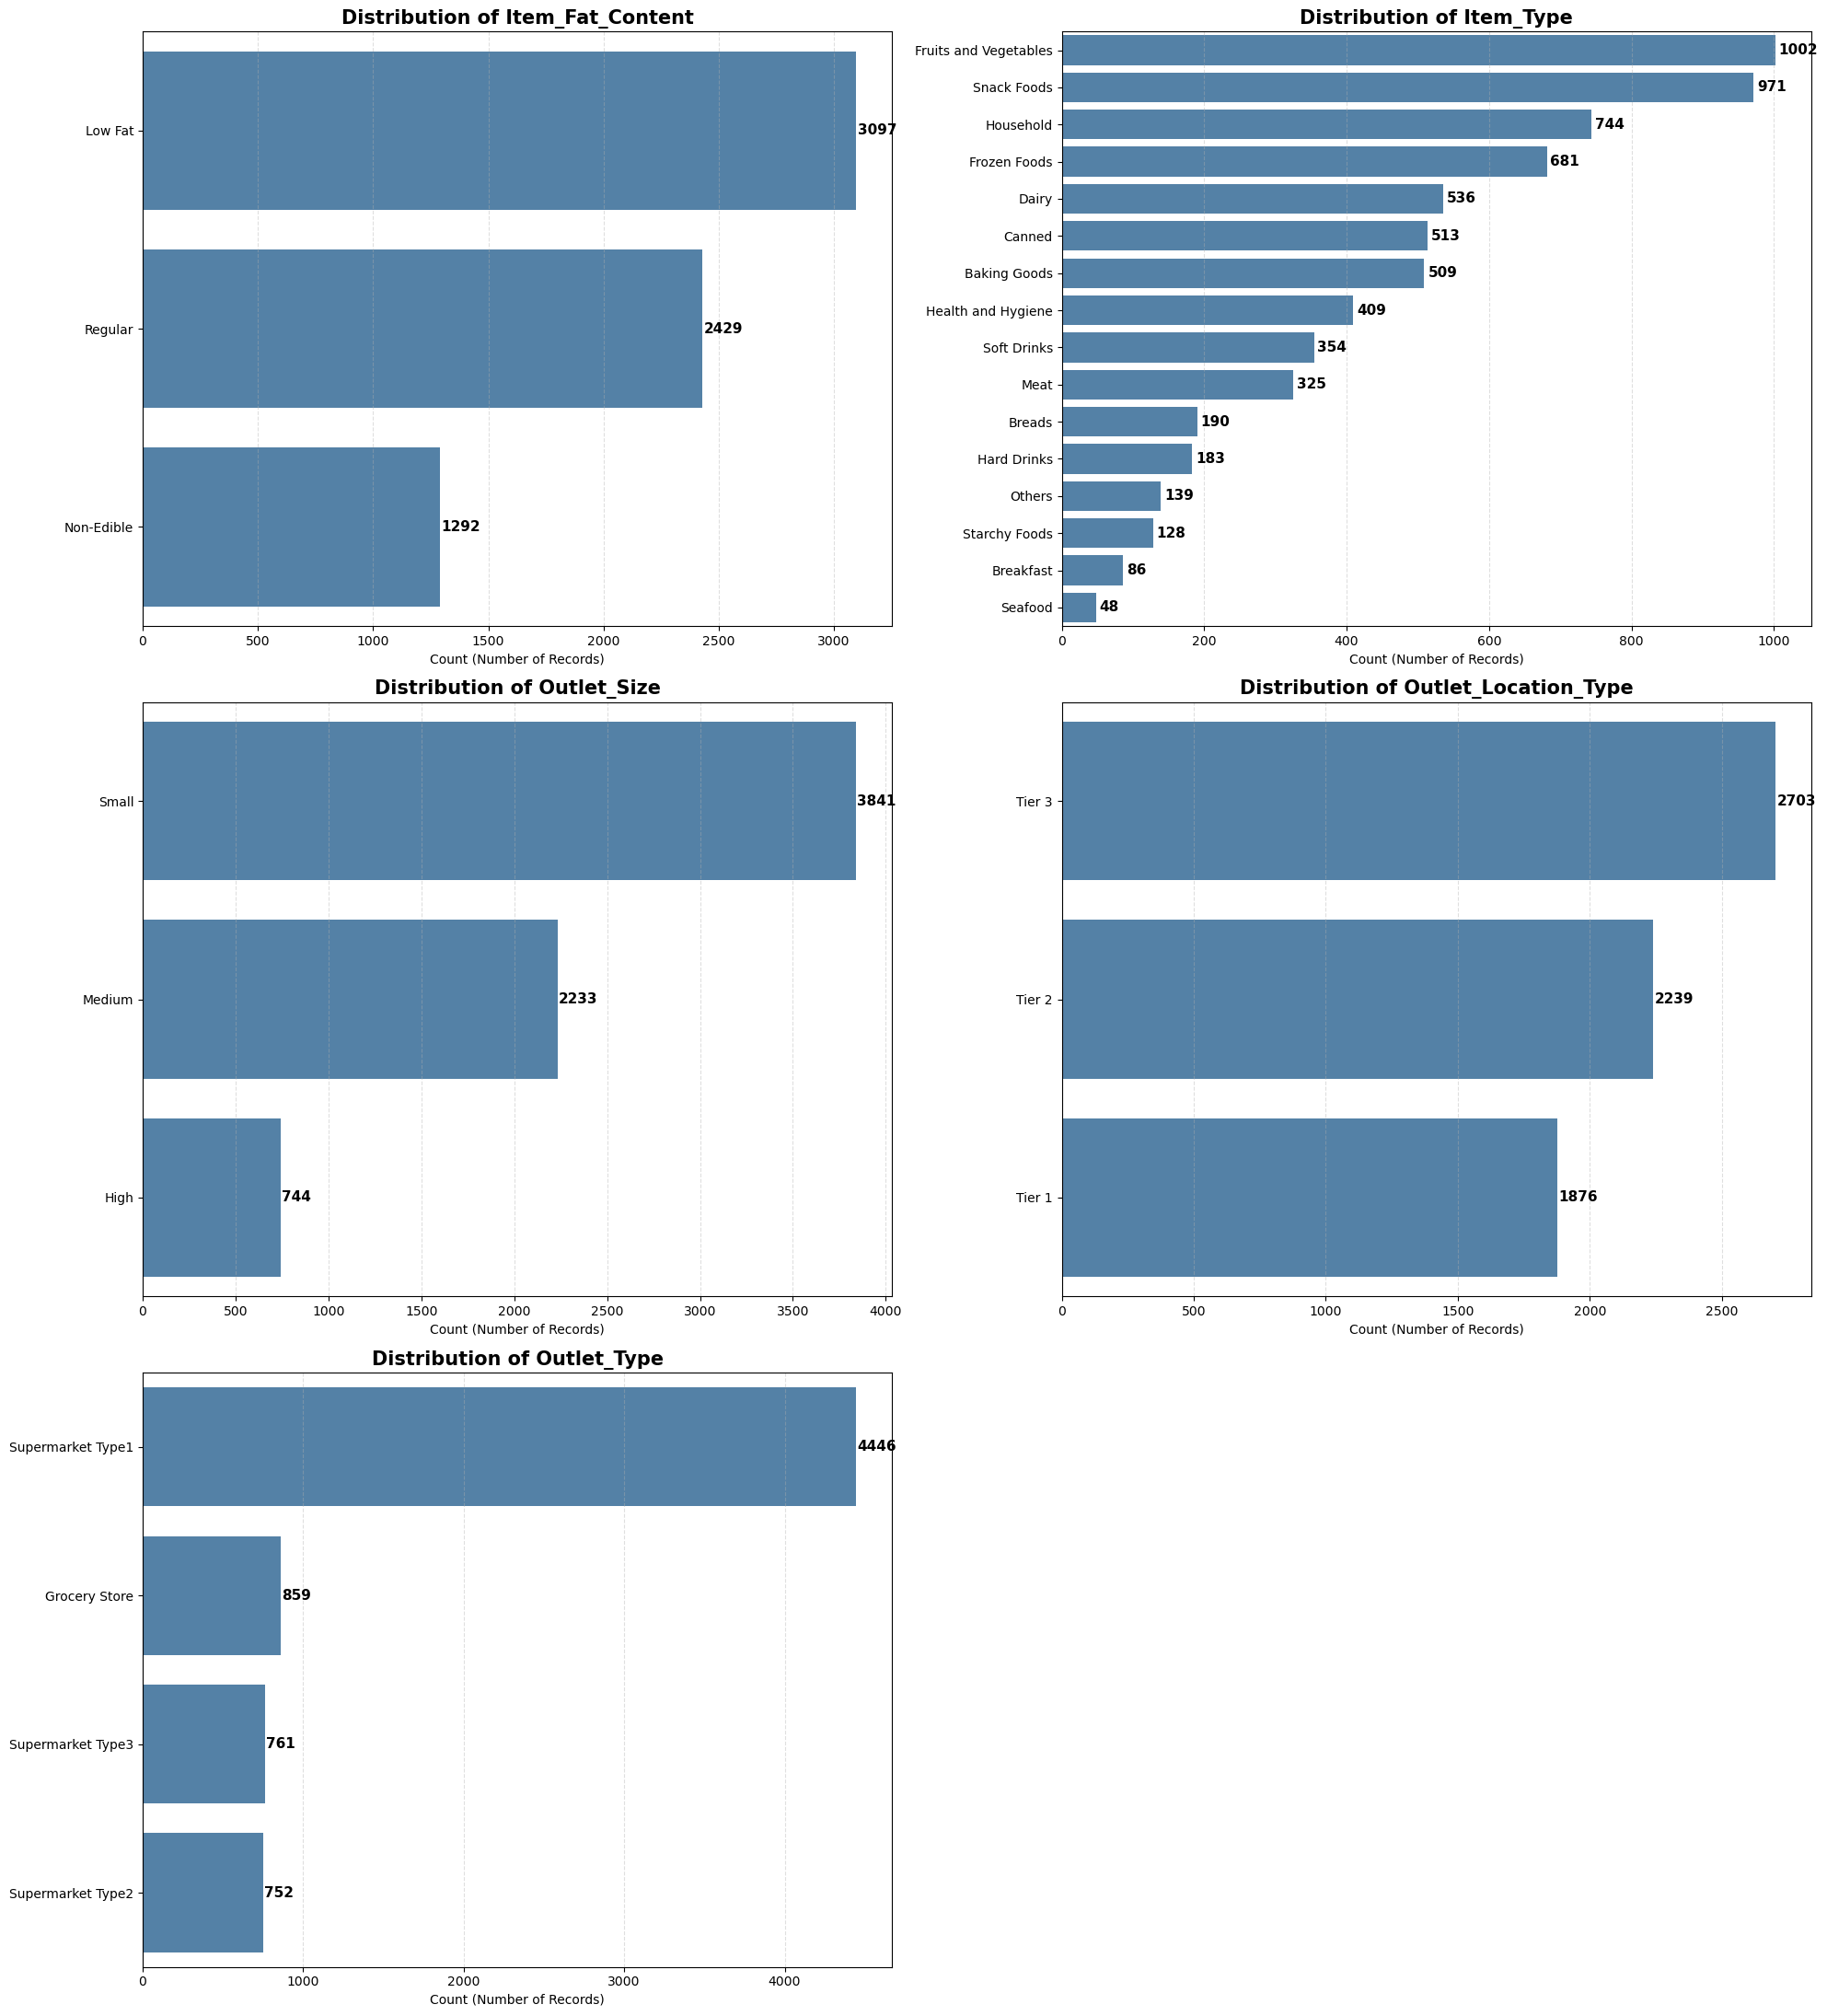

In [63]:
# 1. Define the list of categorical features
cat_features = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

# 2. Set up the figure layout (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(20, 22))
axes = axes.flatten()

# 3. Plot a Countplot for each feature
for i, col in enumerate(cat_features):
    # Sort values in descending order for better visualization
    order = X_train[col].value_counts().index
    
    # Use a single color (steelblue) and remove hue/palette for a cleaner look
    sns.countplot(data=X_train, y=col, ax=axes[i], color='steelblue', order=order)
    
    # Add exact count labels at the end of each bar
    counts = X_train[col].value_counts()
    for index, value in enumerate(counts):
        axes[i].text(value + 5, index, str(value), va='center', fontsize=11, fontweight='bold')

    # Formatting titles and labels
    axes[i].set_title(f'Distribution of {col}', fontweight='bold', fontsize=15)
    axes[i].set_xlabel('Count (Number of Records)')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.4)

# 4. Remove the redundant 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Methodology:**
- **Ordinal Encoding**: Applied to features with an inherent logical order, such as `Outlet_Size` and `Outlet_Location_Type`. Manual mapping was used to ensure the correct hierarchy (e.g., Small < Medium < High).
- **One-Hot Encoding (OHE)**: Applied to nominal features like `Item_Fat_Content`, `Item_Type`, and `Outlet_Type` where no natural ranking exists.
- **Multicollinearity Management**: Implemented the $N-1$ rule (drop_first=True) for all One-Hot encoded variables to avoid the **Dummy Variable Trap**, which is critical for the stability of linear models.

In [64]:
# ==================================================
# 1. ENCODE CATEGORICALS FOR BOTH TRAIN AND TEST
# ==================================================
size_mapping = {'Small': 0, 'Medium': 1, 'High': 2}
location_mapping = {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}
nominal_cols = ['Item_Fat_Content', 'Outlet_Type', 'Item_Type']

# X_train
X_train['Outlet_Size'] = X_train['Outlet_Size'].map(size_mapping)
X_train['Outlet_Location_Type'] = X_train['Outlet_Location_Type'].map(location_mapping)
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)

# X_test
X_test['Outlet_Size'] = X_test['Outlet_Size'].map(size_mapping)
X_test['Outlet_Location_Type'] = X_test['Outlet_Location_Type'].map(location_mapping)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

### 1.4 Final Feature Integration & Dataset Assembly

In [65]:
import pandas as pd

# ==================================================
# 1. EXTRACT CATEGORICAL & NUMERICAL FEATURE LISTS
# ==================================================
num_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']

# Select all columns that are NOT in the numerical list (these are our encoded categoricals)
cat_features_encoded = [col for col in X_train.columns if col not in num_features]

# ==================================================
# 2. MERGE SCALED NUMERICALS WITH ENCODED CATEGORICALS
# ==================================================
# StandardScaler version
X_train_std_final = pd.concat([X_train_std[num_features], X_train[cat_features_encoded]], axis=1)
X_test_std_final  = pd.concat([X_test_std[num_features],  X_test[cat_features_encoded]], axis=1)

# RobustScaler version
X_train_rob_final = pd.concat([X_train_rob[num_features], X_train[cat_features_encoded]], axis=1)
X_test_rob_final  = pd.concat([X_test_rob[num_features],  X_test[cat_features_encoded]], axis=1)

# PowerTransformer version
X_train_pwr_final = pd.concat([X_train_pwr[num_features], X_train[cat_features_encoded]], axis=1)
X_test_pwr_final  = pd.concat([X_test_pwr[num_features],  X_test[cat_features_encoded]], axis=1)

# ==================================================
# 3. VERIFICATION & PREVIEW (FEATURES)
# ==================================================
print("--- Shapes of Final Training Datasets ---")
print(f"StandardScaler Final Shape:   {X_train_std_final.shape}")
print(f"RobustScaler Final Shape:     {X_train_rob_final.shape}")
print(f"PowerTransformer Final Shape: {X_train_pwr_final.shape}")

print("\n--- Quick Preview (Features) ---")
display(X_train_std_final.head())
display(X_train_rob_final.head())
display(X_train_pwr_final.head())

# ==================================================
# 4. TARGET VARIABLE PREVIEW (ACTUAL VS TRANSFORMED)
# ==================================================
print("\n--- Target Variable Shapes ---")
print(f"Original Target Shape: {y_train[target_col].shape}")
print(f"Box-Cox Target Shape:  {y_train_boxcox.shape}")

print("\n--- Target Variable Preview (First 5 rows) ---")
target_preview_df = pd.DataFrame({
    'Original Sales (y_train)': y_train[target_col].values[:5],
    f'Box-Cox Transformed (λ={fitted_lambda:.4f})': y_train_boxcox[:5]
})
display(target_preview_df)

--- Shapes of Final Training Datasets ---
StandardScaler Final Shape:   (6818, 26)
RobustScaler Final Shape:     (6818, 26)
PowerTransformer Final Shape: (6818, 26)

--- Quick Preview (Features) ---


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Outlet_Size,Outlet_Location_Type,Item_Fat_Content_Non-Edible,Item_Fat_Content_Regular,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,-0.733786,-0.706196,0.470709,-0.136169,1,0,False,True,True,False,...,True,False,False,False,False,False,False,False,False,False
1,1.096432,-0.460250,0.457877,-0.493521,0,1,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,1.010304,0.114126,-0.482625,0.102066,0,0,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False
3,-0.986786,-0.813671,-1.603553,-0.493521,0,1,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4,-0.012465,1.339238,0.218375,0.102066,0,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Outlet_Size,Outlet_Location_Type,Item_Fat_Content_Non-Edible,Item_Fat_Content_Regular,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,-0.388649,-0.342357,0.292208,0.000000,1,0,False,True,True,False,...,True,False,False,False,False,False,False,False,False,False
1,0.660086,-0.159402,0.283549,-0.176471,0,1,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,0.610734,0.267869,-0.351127,0.117647,0,0,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False
3,-0.533621,-0.422306,-1.107559,-0.176471,0,1,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4,0.024676,1.179212,0.121927,0.117647,0,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Outlet_Size,Outlet_Location_Type,Item_Fat_Content_Non-Edible,Item_Fat_Content_Regular,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,-0.694087,-0.709824,0.514240,0.057381,1,0,False,True,True,False,...,True,False,False,False,False,False,False,False,False,False
1,1.079738,-0.337202,0.502360,-0.332524,0,1,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,1.004327,0.371275,-0.419613,0.287310,0,0,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False
3,-0.977988,-0.888096,-1.740484,-0.332524,0,1,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4,0.054444,1.352381,0.277605,0.287310,0,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False



--- Target Variable Shapes ---
Original Target Shape: (6818,)
Box-Cox Target Shape:  (6818,)

--- Target Variable Preview (First 5 rows) ---


,Original Sales (y_train),Box-Cox Transformed (λ=0.3461)
0,2386.2272,39.751130
1,3103.9596,43.812109
2,1125.2020,29.988727
3,284.2966,17.553242
4,4224.5010,49.067472


## 2. Model Construction & Prediction

**Objective:** To systematically build, train, and generate predictions using Multiple Linear Regression across various data preprocessing pipelines. By testing multiple scaling methods and target transformations, we aim to identify the optimal configuration that satisfies the algorithm's mathematical assumptions (e.g., normality, homoscedasticity) and yields the highest predictive accuracy.

**Design Decisions & Rationale for Model Variants:**
Linear Regression (Ordinary Least Squares) is highly sensitive to the scale of features, the presence of outliers, and the distribution shape of the data. To isolate and solve these issues, we designed four specific variants:

1. **Baseline Model (Raw Features + Raw Target):** 
    * *Rationale:* Acts as our experimental control. By feeding the algorithm raw, unscaled, and heavily right-skewed data, we establish a "worst-case" performance benchmark. This allows us to quantify exactly how much value our feature engineering and transformation pipeline actually adds.
2. **Standard-BoxCox Model (StandardScaler + Box-Cox Target):**
   * *Rationale:* Standardizes features to have a mean of $0$ and a standard deviation of $1$ ($Z$-score normalization). This ensures that features with larger magnitudes (like `Item_MRP`) do not mathematically dominate smaller features (like `Item_Weight`). However, it tests whether basic scaling is sufficient, as `StandardScaler` remains vulnerable to outliers.
3. **Robust-BoxCox Model (RobustScaler + Box-Cox Target):**
   * *Rationale:* Directly addresses the presence of extreme values identified during EDA (such as outliers in `Item_Visibility`). By scaling based on the Median and Interquartile Range (IQR) rather than the mean, this variant tests if mitigating outlier influence on the feature space improves the model's error metrics.
4. **Power-BoxCox Model (PowerTransformer + Box-Cox Target):**
   * *Rationale:* The most mathematically rigorous variant for a linear algorithm. It uses the Yeo-Johnson method to aggressively transform all skewed continuous features into a Gaussian-like (normal) distribution, pairing perfectly with the Box-Cox transformed target. This variant explicitly fulfills the core normality assumptions of Linear Regression, theoretically offering the most stable and accurate predictions.

**Methodology Details:**
* **Target Normalization:** The Box-Cox Transformation was applied to the target variable to correct its strong right-skewness, preventing the model from being penalized heavily by extreme high-sales data points.
* **Prediction Inversion:** Because the transformed models output predictions in the Box-Cox space, the `inv_boxcox()` function was applied to reverse the transformation. This critical step mathematically converts the predictions back to the original currency scale, allowing for an accurate, apples-to-apples comparison with the actual ground truth during evaluation.

In [ ]:
# Dictionary to store the final predictions in their original scale
predictions_dict = {}

# Variant 1: Baseline Model (Raw Features + Raw Target)
# For the baseline, we use the unscaled features and the original target variable
X_train_base_final = pd.concat([X_train[num_features], X_train[cat_features_encoded]], axis=1)
X_test_base_final  = pd.concat([X_test[num_features],  X_test[cat_features_encoded]], axis=1)

lr_base = LinearRegression()
lr_base.fit(X_train_base_final, y_train[target_col])
pred_base = lr_base.predict(X_test_base_final)

# Linear Regression on raw data can predict negative sales; we floor them to 0
predictions_dict['Baseline Model'] = np.maximum(pred_base, 0) 


# Variant 2: Standard-BoxCox Model
lr_std = LinearRegression()
lr_std.fit(X_train_std_final, y_train_boxcox)
pred_std_bc = lr_std.predict(X_test_std_final)
# Invert Box-Cox: Transform predictions back to the original sales currency (-1 to offset the +1)
predictions_dict['Standard-BoxCox Model'] = inv_boxcox(pred_std_bc, fitted_lambda) - 1

# Variant 3: Robust-BoxCox Model
lr_rob = LinearRegression()
lr_rob.fit(X_train_rob_final, y_train_boxcox)
pred_rob_bc = lr_rob.predict(X_test_rob_final)
# Invert Box-Cox
predictions_dict['Robust-BoxCox Model'] = inv_boxcox(pred_rob_bc, fitted_lambda) - 1


# Variant 4: Power-BoxCox Model
lr_pwr = LinearRegression()
lr_pwr.fit(X_train_pwr_final, y_train_boxcox)
pred_pwr_bc = lr_pwr.predict(X_test_pwr_final)

# Invert Box-Cox
predictions_dict['Power-BoxCox Model'] = inv_boxcox(pred_pwr_bc, fitted_lambda) - 1

# VERIFICATION
print("--- Prediction Shapes Verification ---")
for model_name, preds in predictions_dict.items():
    print(f"{model_name}: {preds.shape}")

--- Prediction Shapes Verification ---
Baseline Model: (1705,)
Standard-BoxCox Model: (1705,)
Robust-BoxCox Model: (1705,)
Power-BoxCox Model: (1705,)


## 3. Model Evaluation

**Objective:** To quantitatively assess and compare the predictive performance of all four Linear Regression variants using standard evaluation metrics.

**Metrics Used:**
* **MAE (Mean Absolute Error):** Measures the average magnitude of errors in the original sales currency without penalizing extreme errors.
* **MSE (Mean Squared Error) & RMSE (Root Mean Squared Error):** Heavily penalizes large errors. RMSE provides the error in the same unit as the target variable (Sales), making it highly interpretable.
* **$R^2$ (Coefficient of Determination):** Indicates the proportion of the variance in the target variable that is predictable from the features.

In [67]:
# List to save results
evaluation_results = []

# Get actual target values
ground_truth = y_test[target_col].values

# Calculate metrics for each model
for model_name, y_pred in predictions_dict.items():
    mae = mean_absolute_error(ground_truth, y_pred)
    mse = mean_squared_error(ground_truth, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(ground_truth, y_pred)
    
    # Add results to list
    evaluation_results.append({
        'Model Variant': model_name, 
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse, 
        'R-squared': r2
    })

# Convert list to DataFrame and sort by RMSE
eval_df = pd.DataFrame(evaluation_results).sort_values(by='RMSE').reset_index(drop=True)

# Format the numbers for a cleaner look
formatted_eval_df = eval_df.style.format({
    'MAE': '{:,.2f}',
    'MSE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'R-squared': '{:.4f}'
})

# Show the table
display(formatted_eval_df)

,Model Variant,MAE,MSE,RMSE,R-squared
0,Power-BoxCox Model,717.59,"1,071,344.93","1,035.06",0.6058
1,Standard-BoxCox Model,725.29,"1,087,832.03","1,042.99",0.5998
2,Robust-BoxCox Model,725.29,"1,087,832.03","1,042.99",0.5998
3,Baseline Model,756.13,"1,101,393.68","1,049.47",0.5948


**Empirical Results & Analysis**

Based on the evaluation metrics, we can draw several critical conclusions regarding the model variants:

**1. The Superiority of Full Normalization (Power-BoxCox):**
The `Power-BoxCox Model` achieved the highest predictive performance, boasting the lowest RMSE ($1,035.06$) and the highest $R^2$ ($0.6058$). By applying the Yeo-Johnson transformation to the features and Box-Cox to the target, we successfully mitigated skewness on both sides of the equation, creating the optimal environment for the OLS (Ordinary Least Squares) algorithm. It reduced the average prediction error (MAE) by nearly $40 compared to the baseline.

**2. Scale Invariance in Standard OLS:**
Interestingly, the `Standard-BoxCox` and `Robust-BoxCox` models yielded identical evaluation metrics ($RMSE = 1,042.99$, $R^2 = 0.5998$). This is mathematically consistent with unpenalized Linear Regression. Shifting and scaling features (via Z-score or IQR) changes the magnitude of the learned coefficients ($\beta$) but does not alter the underlying linear relationship or the final predicted values ($\hat{y}$). 

**3. The Linear Ceiling ($R^2 \approx 0.60$):**
Despite rigorous transformations, the highest $R^2$ achieved is roughly $60.5\%$. This suggests that Linear Regression has reached its theoretical limit for this dataset. The remaining $39.5\%$ of unexplained variance implies that the true relationship between the features (e.g., Visibility, Outlet Type) and Sales is partially non-linear. Future work could involve exploring tree-based ensemble models, such as XGBoost, to capture these complex non-linear interactions and further minimize the RMSE.

## 4. Model Diagnostics & Visual Analysis

**Objective:** To visually validate the core mathematical assumptions of Linear Regression and compare how different transformations affect the model's behavior. 

To ensure our model is reliable and not systematically biased, we examine three types of diagnostic plots for each of the four variants:

### 4.1 Predicted vs. Actual Sales (The Accuracy Check)
* **What it measures:** The correlation between the model's guesses and the ground truth.
* **Ideal Scenario:** All data points should cluster tightly along the **red dashed line ($y = x$)**. 
* **Insight:** If points deviate significantly from this line at high sales values, it indicates the model struggles to predict "best-selling" items (outliers).



### 4.2 Residual Plot (The Homoscedasticity Check)
* **What it measures:** The relationship between the predicted values and the errors (residuals).
* **Ideal Scenario:** A random "cloud" of points scattered evenly around the **horizontal zero-line ($y = 0$)**. 
* **Insight:** 
    * **Good:** No visible pattern suggests the model's error rate is consistent across all sales ranges (**Homoscedasticity**).
    * **Bad:** A "funnel" or "U-shape" indicates that the model's accuracy changes depending on the price, which violates linear assumptions (**Heteroscedasticity**).


### 4.3 Error Distribution (The Normality Check)
* **What it measures:** The frequency and spread of the prediction errors.
* **Ideal Scenario:** A symmetrical **Bell Curve (Normal Distribution)** centered exactly at $0$.
* **Insight:** 
    * If the distribution is skewed to the right or left, the model is systematically over-predicting or under-predicting. 
    * A tight, tall curve at zero indicates that most errors are very small, which is the hallmark of a high-performing model.

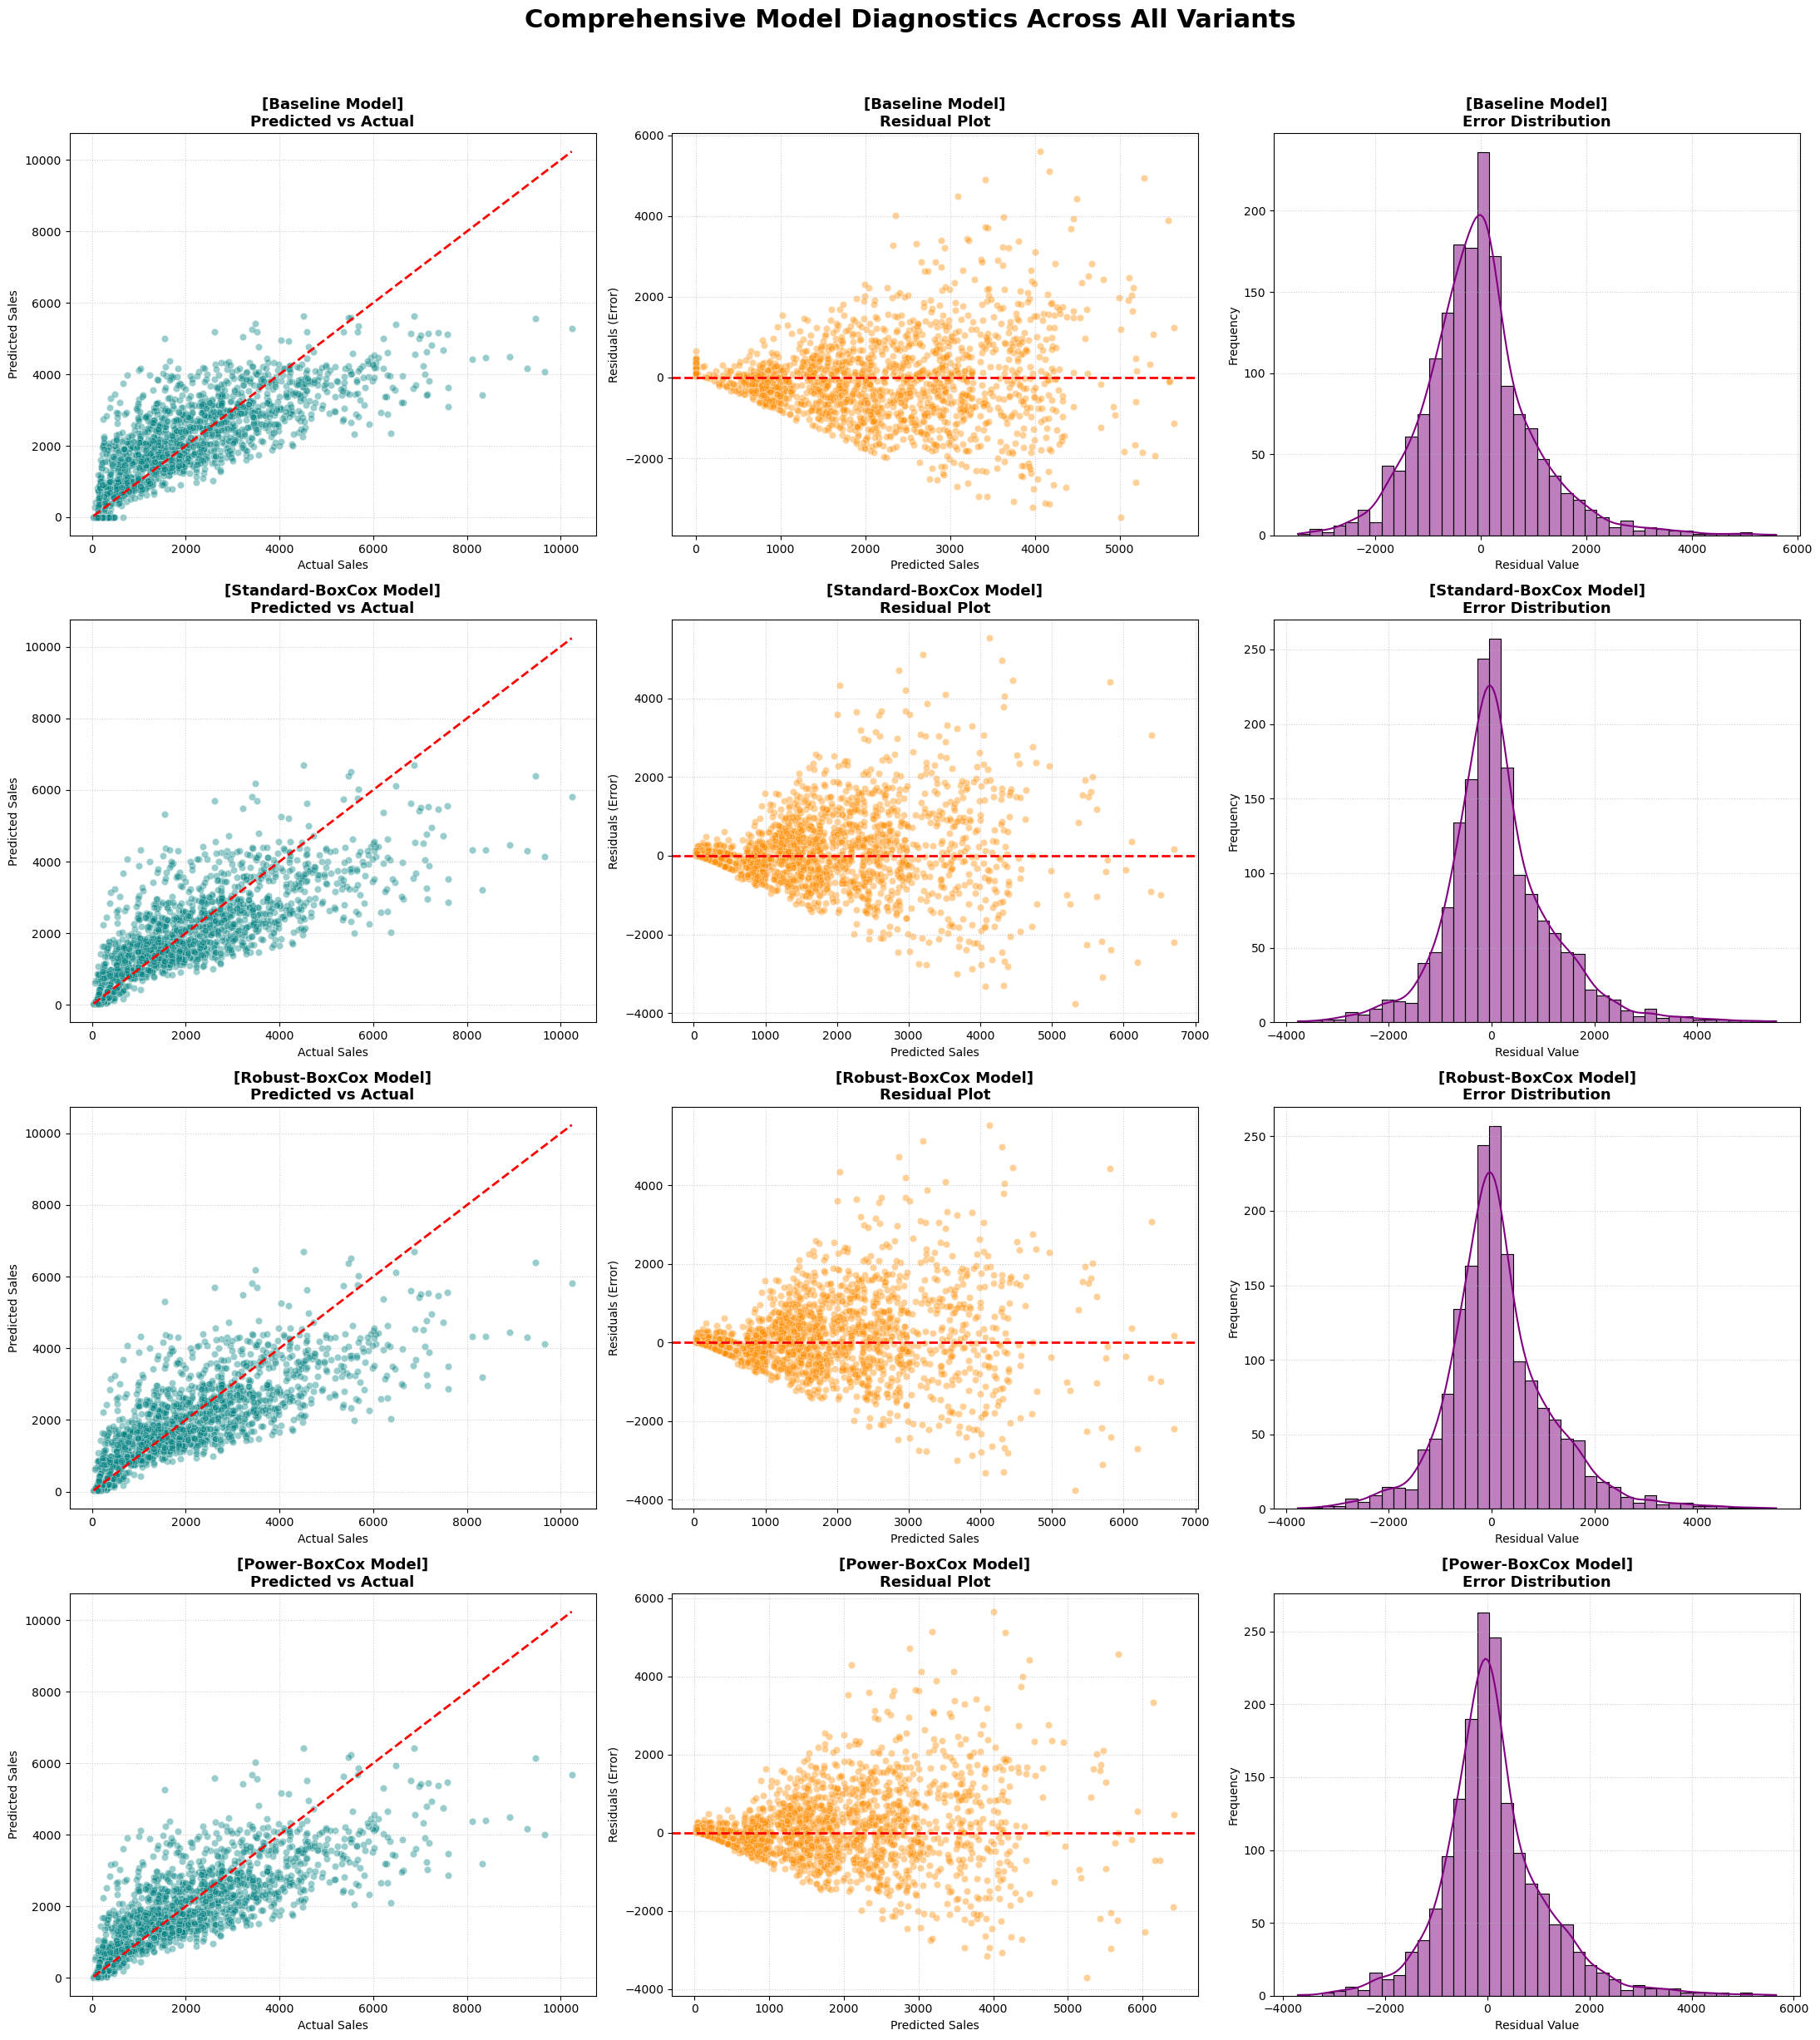

In [68]:
# 1. Get actual target values
actual_vals = y_test[target_col].values
min_val = actual_vals.min()
max_val = actual_vals.max()

# 2. Create a grid with 4 rows (models) and 3 columns (plots)
fig, axes = plt.subplots(4, 3, figsize=(22, 24))

# 3. Loop through all 4 models in the dictionary
for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
    
    # Calculate residuals (errors)
    residuals = actual_vals - y_pred
    
    # --------------------------------------------------
    # Column 0: Predicted vs Actual
    # --------------------------------------------------
    sns.scatterplot(x=actual_vals, y=y_pred, alpha=0.4, color='teal', ax=axes[i, 0])
    # Draw perfect prediction line (y = x)
    axes[i, 0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    axes[i, 0].set_title(f'[{model_name}]\nPredicted vs Actual', fontweight='bold', fontsize=13)
    axes[i, 0].set_xlabel('Actual Sales')
    axes[i, 0].set_ylabel('Predicted Sales')
    axes[i, 0].grid(True, linestyle=':', alpha=0.6)
    
    # --------------------------------------------------
    # Column 1: Residual Plot
    # --------------------------------------------------
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, color='darkorange', ax=axes[i, 1])
    # Draw zero error line
    axes[i, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    axes[i, 1].set_title(f'[{model_name}]\nResidual Plot', fontweight='bold', fontsize=13)
    axes[i, 1].set_xlabel('Predicted Sales')
    axes[i, 1].set_ylabel('Residuals (Error)')
    axes[i, 1].grid(True, linestyle=':', alpha=0.6)
    
    # --------------------------------------------------
    # Column 2: Error Distribution
    # --------------------------------------------------
    sns.histplot(residuals, kde=True, color='purple', bins=40, ax=axes[i, 2])
    
    axes[i, 2].set_title(f'[{model_name}]\nError Distribution', fontweight='bold', fontsize=13)
    axes[i, 2].set_xlabel('Residual Value')
    axes[i, 2].set_ylabel('Frequency')
    axes[i, 2].grid(True, linestyle=':', alpha=0.6)

# 4. Add main title and adjust layout
plt.suptitle("Comprehensive Model Diagnostics Across All Variants", fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Extracting & Ranking Feature Importance
To interpret the model, we extract coefficients from the best-performing model (**Power-BoxCox Linear Regression**).

In [69]:
# 1. Map feature names to their coefficients from the best model
# We use lr_pwr as it achieved the highest R-squared
features = X_train_pwr_final.columns
coefs = lr_pwr.coef_

# 2. Create a summary DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Abs_Impact': abs(coefs) # Calculate absolute value for ranking strength
})

# 3. Sort by absolute impact to find the strongest relationships
importance_df = importance_df.sort_values(by='Abs_Impact', ascending=False).reset_index(drop=True)

print("--- Features with Relationship to Sales ---")
print(importance_df[['Feature', 'Coefficient']])



--- Features with Relationship to Sales ---
                            Feature  Coefficient
0     Outlet_Type_Supermarket Type3    27.042724
1     Outlet_Type_Supermarket Type1    18.716726
2     Outlet_Type_Supermarket Type2    15.638861
3                          Item_MRP     6.614281
4                 Item_Type_Seafood     0.950391
5                   Item_Type_Dairy    -0.738393
6                       Outlet_Size     0.597997
7                      Outlet_Years    -0.525819
8             Item_Type_Soft Drinks    -0.319606
9      Item_Type_Health and Hygiene     0.306556
10           Item_Type_Frozen Foods    -0.274673
11         Item_Fat_Content_Regular     0.252743
12              Item_Type_Breakfast    -0.227235
13             Outlet_Location_Type    -0.221458
14                 Item_Type_Canned     0.219115
15          Item_Type_Starchy Foods    -0.195640
16              Item_Type_Household    -0.154623
17  Item_Type_Fruits and Vegetables     0.137843
18                 Item_T

### 4.5 Interpretation and Insights

**1. Hierarchy of Influence (Coefficient Magnitude)**
The model distinguishes between high-impact structural factors and low-impact product attributes.

- **Primary Drivers (Structural):** The store's operational format is the single most powerful predictor. **Supermarket Type 3 (+27.04)**, **Type 1 (+18.72)**, and **Type 2 (+15.64)** dominate the model. This reveals that the infrastructure and capacity of the outlet contribute significantly more to sales volume than any individual product characteristic.

- **Secondary Driver (Value):** `Item_MRP` **(+6.61)** acts as the critical continuous anchor. It maintains a stable positive relationship, confirming that revenue scales directly with the price point of the inventory.

**2. Identified Negative Correlations**
The data identifies specific factors that statistically "penalize" the predicted sales figure:

- **Temporal Decline**: `Outlet_Years` *(-0.53)* shows that for every year an outlet has been in operation, there is a measurable decrease in predicted sales. This reveals a "legacy penalty" where older establishments underperform compared to newer ones.

- **Specific Categories**: Items categorized as **Dairy (-0.74)** and **Soft Drinks (-0.32)** are associated with lower sales relative to the baseline, suggesting these segments are underperforming within the Big Mart ecosystem.

- **The Visibility Paradox**: **Item_Visibility (-0.10)** demonstrates a counter-intuitive inverse relationship. Increasing a product's display percentage does not lead to higher sales in this dataset, suggesting that shelf-space allocation may currently be inefficient.

**3. Statistical Neutrality (Zero-Impact Factors)**
Several variables traditionally assumed to be important are revealed by the model to have no significant relationship with sales:

- **Physical Attributes**: `Item_Weight` **(-0.06)** has a coefficient near zero, proving it is irrelevant to consumer purchasing behavior.

- **Commodity Types**: Categories like **Meat** **(+0.015)** and **Breads (+0.03)** show negligible impact, indicating they are neutral contributors to the overall revenue model.


## 5. Save Model Checkpoint

In [ ]:
pickle.dump(y_test, open("saved_model/y_test.pkl", "wb"))
pickle.dump(y_pred, open("saved_model/y_pred.pkl", "wb"))

# =========================
# 1. SAVE MODEL (Power-BoxCox - best model)
# =========================
with open("saved_model/model.pkl", "wb") as f:
    pickle.dump(lr_pwr, f)

# =========================
# 2. SAVE SCALER (PowerTransformer)
# =========================
with open("saved_model/scaler.pkl", "wb") as f:
    pickle.dump(scaler_pwr, f)

# =========================
# 3. SAVE BOX-COX LAMBDA
# =========================
with open("saved_model/lambda.pkl", "wb") as f:
    pickle.dump(fitted_lambda, f)

# =========================
# 4. SAVE FEATURE COLUMNS
# =========================
with open("saved_model/columns.pkl", "wb") as f:
    pickle.dump(X_train_pwr_final.columns.tolist(), f)